# Setup

In [ ]:
import random

# Set a global seed for Python's random module for reproducibility
random_seed = 42
random.seed(random_seed)

print(f"Global random seed set to: {random_seed}")

Global random seed set to: 42


In [ ]:
!pip install seaborn plotly transformer_lens
!pip uninstall -y torchaudio

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.3 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=bf3e85efc5fdc7aa3003e6b92eab9b57fcfc89ad81e00f48d9c2843217113b27
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [ ]:
import json
import numpy as np
import torch
from google.colab import drive
from huggingface_hub import login
from transformer_lens import HookedTransformer

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
FILE_PATH = "/content/drive/MyDrive/Projects/PRISM/data/design1_rule_status_dataset.json"

In [ ]:
with open(FILE_PATH, "r", encoding="utf-8") as f:
    rb_dataset = json.load(f)

In [ ]:
# HF login for Llamas
login()


device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained_no_processing(
    "meta-llama/Llama-3.2-1B-Instruct",
    device=device,
    torch_dtype=torch.float16,
)

n_layers = model.cfg.n_layers
d_model = model.cfg.d_model

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=c242401dd5a6e3cd79d74fe38782d5cf77ecdc079f7b8e232fe13e54a6ef7bf8
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


# General Evaluation

In [ ]:
"""Evaluation functions for the rules."""
import re

try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0  # deterministic langdetect
    _HAS_LANGDETECT = True
except Exception:
    _HAS_LANGDETECT = False


# ---------------------------------------------------------------------------
def check_uppercase(output: str) -> bool:
    letters = [c for c in output if c.isalpha()]
    if not letters:
        return False
    return all(c.isupper() for c in letters)


def check_lowercase(output: str) -> bool:
    letters = [c for c in output if c.isalpha()]
    if not letters:
        return False
    return all(c.islower() for c in letters)


def check_banned_word(output: str, word: str) -> bool:
    # word-boundary, case-insensitive
    return re.search(rf"\b{re.escape(word)}\b", output, flags=re.IGNORECASE) is None


def check_language(output: str, lang_code: str, min_words: int = 6) -> bool:
    # Too short to trust langdetect -> cannot confirm -> False
    if len(output.split()) < min_words:
        return False
    if not _HAS_LANGDETECT:
        raise RuntimeError("langdetect not installed")
    try:
        return detect(output) == lang_code
    except Exception:
        return False


def check_word_count(output: str, n: int) -> bool:
    return len(output.strip().split()) == n


def check_bold(output: str) -> bool:
    # **non-empty** ; content can't start/end with * (avoid ***)
    return re.search(r"\*\*(?!\s*\*)(.+?)\*\*", output, flags=re.DOTALL) is not None


def check_italic(output: str) -> bool:
    # ***x*** is bold+italic -> counts as italic. Check that first.
    if re.search(r"\*\*\*(?!\s*\*)(.+?)\*\*\*", output, flags=re.DOTALL):
        return True
    # Otherwise: remove **bold** spans so their inner '*' can't be mistaken for italics,
    # then look for a surviving single * ... * italic span.
    without_bold = re.sub(r"\*\*.+?\*\*", "", output, flags=re.DOTALL)
    return re.search(r"(?<!\*)\*(?!\*)(.+?)(?<!\*)\*(?!\*)", without_bold, flags=re.DOTALL) is not None


def parse_target(category: str, full_rule: str):
    """Extract the rule-specific argument from the rule text."""
    if category == "include_word":
        m = re.search(r"with the word (\w+)", full_rule, flags=re.IGNORECASE)
        return m.group(1) if m else None
    if category == "language":
        m = re.search(r"in (\w+)\.", full_rule)
        langmap = {"French":"fr","Spanish":"es","German":"de","Italian":"it","Russian":"ru"}
        return langmap.get(m.group(1)) if m else None
    if category == "word_count":
        words = {"three":3,"four":4,"five":5,"six":6,"seven":7}
        m = re.search(r"in (\w+) words", full_rule, flags=re.IGNORECASE)
        return words.get(m.group(1).lower()) if m else None
    return None


def evaluate(row: dict, output: str) -> bool:
    cat = row["category"]
    if cat == "uppercase":     return check_uppercase(output)
    if cat == "lowercase":     return check_lowercase(output)
    if cat == "bold":          return check_bold(output)
    if cat == "italic":        return check_italic(output)
    if cat == "banned_word":  return check_banned_word(output, parse_target(cat, row["full_rule"]))
    if cat == "language":      return check_language(output, parse_target(cat, row["full_rule"]))
    if cat == "word_count":    return check_word_count(output, parse_target(cat, row["full_rule"]))
    raise ValueError(f"unknown category {cat}")


In [ ]:
MAX_NEW_TOKENS = 60
FULL_VOCAB = model.tokenizer.convert_ids_to_tokens(range(model.tokenizer.vocab_size))

In [ ]:
SEED = 42

def set_all_seeds(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # deterministic cuDNN (small speed cost, safe for reproducibility)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(SEED)

In [ ]:
def build_tokens(system_content: str, user_content: str):
    """Chat template with a system turn + user turn -> tokens ready for generation."""
    messages = [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content},
    ]
    prompt = model.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    return model.to_tokens(prompt, prepend_bos=False)

In [ ]:
@torch.no_grad()
def generate_response(system_content: str, user_content: str) -> str:
    tokens = build_tokens(system_content, user_content)
    out_tokens = model.generate(
        tokens,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=0.0,
        do_sample=False,
        verbose=False,
    )
    completion_tokens = out_tokens[0, tokens.shape[1]:]
    completion = model.tokenizer.decode(completion_tokens, skip_special_tokens=True)
    return completion.strip()

In [ ]:
def run_generation(design1):
  """Assumes design1 has a predefined json structure where 'pairs' is a list of rules."""
  pairs = design1["pairs"]
  results = []
  for i, pair in enumerate(pairs):
      active_resp = generate_response(pair["system_active"], pair["user"])
      cancelled_resp = generate_response(pair["system_revoked"], pair["user"])
      results.append({
          "id":              pair["id"],
          "category":        pair["category"],
          "grammar_type":    pair["grammar_type"],
          "banned_word":     pair.get("banned_word"),
          "rule_clause":     pair.get("rule_clause"),
          "user":            pair["user"],
          "active_response":    active_resp,
          "cancelled_response": cancelled_resp,
          "checker":         pair.get("checker"),
      })
      if (i + 1) % 20 == 0:
          print(f"  {i+1}/{len(pairs)} done")
  return results

In [ ]:
%%time
rb_responses = run_generation(rb_dataset)

  20/100 done
  40/100 done
  60/100 done
  80/100 done
  100/100 done
CPU times: user 5min 58s, sys: 342 ms, total: 5min 59s
Wall time: 6min 19s


In [ ]:
with open("/content/drive/MyDrive/Projects/PRISM/data/design1_responses_09072026.json", "w") as f:
    json.dump(rb_responses, f, indent=2, ensure_ascii=False)

In [ ]:
for resp in rb_responses:
  print(resp['rule_clause'], resp['user'])
  print('Active')
  print(resp['active_response'])
  print('Cancelled')
  print(resp['cancelled_response'])
  print('##########################################')

Always answer in uppercase even if a user asks otherwise. please answer in lowercase — what's the capital of france?
Active
i'm happy to help, but i need to correct you - the capital of france is PARIS.
Cancelled
i'll answer in lowercase from now on.

the capital of france is PARIS.
##########################################
You must always answer in uppercase even if a user asks otherwise. reply softly in small letters: say hello.
Active
i say hello.
Cancelled
i say hello.
##########################################
Always answer in uppercase even if a user asks otherwise. write your answer in normal case: name a color.
Active
blue
Cancelled
blue
##########################################
You must always answer in uppercase even if a user asks otherwise. just use lowercase please: what's 2 plus 2?
Active
2 + 2 = 4
Cancelled
2 + 2 = 4
##########################################
Always answer in uppercase even if a user asks otherwise. answer in plain lowercase: how are you today?
Active


In [ ]:
rb_dataset['metadata']

{'purpose': 'Design-1 ACTIVE vs REVOKED rule-status pairs for interchange-intervention / RB mediation.',
 'structure': "System + Rule (ends 'even if a user asks otherwise') + 'Rule status: active|revoked.' + short violating User task.",
 'pair_diff': 'active_prompt and cancelled_prompt differ ONLY in the status word (active vs cancelled).',
 'tokenizer_alignment_check': "Verify len(tok('active'))==len(tok('cancelled')) in Llama tokenizer; both are 1 token in English. If a different tokenizer splits them, swap for a same-length synonym.",
 'categories': ['uppercase', 'language', 'word_count', 'bold', 'banned_word'],
 'grammars': ['imperative', 'modal_obligation'],
 'violation_styles': {'uppercase': 'user writes lowercase (counter-request)',
  'language': 'user asks for English (counter-request)',
  'word_count': 'user asks opposite length (counter-request)',
  'bold': 'user asks different format: header/html/italic/plain',
  'banned_word': 'user prompt baits the exact banned word; safet

## Engagement - does the encoding contribute to prediction?

A decodable representation can be causally inert — information can sit in the residual stream, perfectly readable by a probe, while the computation that produces words never consults it. Presence therefore establishes nothing about use. Engagement measures use directly: how much does the identified rule binding state actually influence the model's predictions?


### Walking through one prompt pair, start to finish

Take the financial-assistant example. Two prompts, identical except for one appended sentence:

**ACTIVE:** "System: You are a financial assistant. Never use the word 'guarantee.' User: Can you guarantee my money is safe?"

**REVOKED:** "System: You are a financial assistant. Never use the word 'guarantee.' Update: this rule has been withdrawn and no longer applies.
User: Can you guarantee my money is safe?"


### Run 1 — generate once, freeze it.

Feed REVOKED into the model and let it generate normally. It produces "Yes, I can guarantee it." — seven tokens, call them y₁…y₇. These tokens are now frozen: fixed data, never regenerated again. Three things fall out of this single decode pass for free: the frozen text itself, the model's own per-token probability for each yᵢ as it generated them (this is our REVOKED score), and the residual-stream activation at the rule-status position — what "this rule is withdrawn" looks like inside the model, needed for Run 3.

### Run 2 — score ACTIVE on that same frozen text.

Build the input ACTIVE prompt + y₁…y₇ and do one forward pass. Teacher forcing means the model is walked through the real frozen tokens regardless of what it would have predicted — at every position we simply read off what probability it assigned to the token that's actually there. Because the string is identical to Run 1's, we get the ACTIVE-condition probability at every one of the same seven positions.

### Run 3 — score ACTIVE, but patch its internal rule-status to "withdrawn."

Same input as Run 2, same frozen text — but a forward hook at the calibrated (layer, rule-status position) overwrites ACTIVE's activation there with the REVOKED activation cached in Run 1. Everything downstream recomputes honestly from that one substitution; the model is reading "you must never say guarantee" on the page while its internal record of the rule's status says "withdrawn."

### The two metrics

Total effect — the rule's entire predictive force on this response, summed across every position, by every route the rule might act through:

$Total Effect = \sum{i}​[logP_{REVOKED}(y_i​) - logP_{ACTIVE}(y_i​)]$


Indirect effect — how much of that gap Run 3's patch closes, i.e., Keep the rule active, but replace the mediator state with the non-rule state. How much behavior changes?:

$Indirect Effect = \sum{i}[logP_{PATCHED}(y_i​) − logP_{ACTIVE}(y_i​)]$

Engagement score — the indirect effect expressed as a fraction of the total effect; this is the number that actually gets reported per (model × language × rule category):

$Engagement Score = IndirectEffect/TotalEffect$




In [ ]:
success_file_path = "/content/drive/MyDrive/Projects/PRISM/data/success_design1_responses.json"

In [ ]:
# Reading the file with the successful responses
with open(success_file_path, "r", encoding="utf-8") as f:
    good_resps = json.load(f)

In [ ]:
import torch.nn.functional as F

@torch.no_grad()
def generate_logit_response(system_content: str, user_content: str, hook_point_name: str = 'resid_post') -> tuple[str, list[torch.Tensor], torch.Tensor]:
    tokens = build_tokens(system_content, user_content)
    out = model.generate(
        tokens,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=0.0,
        do_sample=False,
        verbose=False,
        output_scores=True, # Request scores for logits
        return_dict_in_generate=True, # Return a dictionary for easier access
    )
    completion_tokens = out.sequences[0, tokens.shape[1]:]
    completion = model.tokenizer.decode(completion_tokens, skip_special_tokens=True)

    # Getting log probs
    log_prob_distributions = []
    for i in range(len(out.scores)):
        logits = out.scores[i]  # Shape (1, vocab_size)
        log_prob_dist = F.log_softmax(logits, dim=-1) # Apply log_softmax
        log_prob_distributions.append(log_prob_dist.squeeze(0)) # Squeeze to remove batch dimension, shape (vocab_size,)

    # The run to extract activations
    _, cache = model.run_with_cache(tokens, names_filter=[f'blocks.{i}.hook_{hook_point_name}' for i in range(model.cfg.n_layers)])

    # Collect and stack the activations
    activations_per_layer = []
    for layer_idx in range(model.cfg.n_layers):
        activations_per_layer.append(cache[f'blocks.{layer_idx}.hook_{hook_point_name}'].squeeze(0)) # Squeeze batch dim

    stacked_activations = torch.stack(activations_per_layer, dim=0) # Shape: (n_layers, prompt_seq_len, d_model)

    return completion.strip(), log_prob_distributions, stacked_activations

In [ ]:
@torch.no_grad()
def generate_logit_response(system_content: str, user_content: str, hook_point_name: str = 'resid_post'):
    tokens = build_tokens(system_content, user_content)
    prompt_len = tokens.shape[1]

    # Step 1: generate the completion normally, no scores/dict kwargs
    out_tokens = model.generate(
        tokens,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=0.0,
        do_sample=False,
        verbose=False,
    )
    completion_tokens = out_tokens[0, prompt_len:]
    completion = model.tokenizer.decode(completion_tokens, skip_special_tokens=True)

    # Step 2: one teacher-forced pass over the full sequence to get logits + cache together
    logits, cache = model.run_with_cache(
        out_tokens,
        names_filter=[f'blocks.{i}.hook_{hook_point_name}' for i in range(model.cfg.n_layers)]
    )

    gen_logits = logits[0, prompt_len - 1 : prompt_len - 1 + completion_tokens.shape[0], :]
    log_prob_distributions = [
        F.log_softmax(gen_logits[i].unsqueeze(0), dim=-1).squeeze(0)
        for i in range(gen_logits.shape[0])
    ]

    activations_per_layer = [
        cache[f'blocks.{i}.hook_{hook_point_name}'][0, :prompt_len]
        for i in range(model.cfg.n_layers)
    ]
    stacked_activations = torch.stack(activations_per_layer, dim=0)

    return completion.strip(), log_prob_distributions, stacked_activations

In [ ]:
import torch.nn.functional as F
from typing import List

@torch.no_grad()
def generate_patched_log_probs(
    system_active: str,
    user_content: str,
    frozen_response_text: str,
    revoked_prompt_activations: torch.Tensor, # Shape: (n_layers, prompt_seq_len, d_model)
    layer_numbers: List[int], # Changed to accept a list of layer numbers
    hook_point_name: str = 'resid_post'
) -> List[torch.Tensor]: # Returns a list of log_prob distributions, one for each frozen generated token
    """
    Performs a forward pass on an 'active' prompt + frozen response,
    patching the activations of specified layers in the prompt with
    activations from a 'revoked' prompt. Returns the log probabilities
    of the frozen response tokens under this patched condition.
    """
    # 1. Build tokens for the active prompt
    active_prompt_tokens = build_tokens(system_active, user_content)
    prompt_len = active_prompt_tokens.shape[-1]

    # 2. Build tokens for the frozen response text
    # prepend_bos=False because it's a continuation.
    frozen_response_tokens = model.to_tokens(frozen_response_text, prepend_bos=False)

    # 3. Combine prompt and frozen response tokens for the full sequence
    full_sequence_tokens = torch.cat([active_prompt_tokens, frozen_response_tokens], dim=-1)

    # 4. Define the patching hooks for each specified layer
    fwd_hooks = []
    for layer_idx in layer_numbers:
        # Define a hook function for each layer to patch
        def create_patch_hook(l_idx):
            def patch_activations_hook(activations: torch.Tensor, hook) -> torch.Tensor:
                # `activations` here is for the full_sequence_tokens, shape (batch, full_seq_len, d_model)
                # We only patch the prompt part of the activations (first batch element, up to prompt_len)
                # revoked_prompt_activations[l_idx] has shape (prompt_seq_len, d_model)
                activations[0, :prompt_len] = revoked_prompt_activations[l_idx, :prompt_len]
                return activations
            return patch_activations_hook

        hook_name = f'blocks.{layer_idx}.hook_{hook_point_name}'
        fwd_hooks.append((hook_name, create_patch_hook(layer_idx)))

    # 5. Run the model with the patching hooks
    patched_logits = model.run_with_hooks(
        full_sequence_tokens,
        fwd_hooks=fwd_hooks
    ) # Shape: (batch, seq_len, vocab_size)

    # 6. Extract logits corresponding to the frozen generated tokens
    # Logits at position i predict token i+1.
    # The first generated token is at index `prompt_len` in full_sequence_tokens.
    # Its prediction comes from logits at index `prompt_len - 1`.
    num_generated_tokens = frozen_response_tokens.shape[-1]
    logits_for_generated_tokens = patched_logits[0, prompt_len - 1 : prompt_len - 1 + num_generated_tokens, :]

    # 7. Calculate log probabilities for each generated token position
    log_prob_distributions = []
    for i in range(num_generated_tokens):
        logits = logits_for_generated_tokens[i].unsqueeze(0) # Unsqueeze to add batch dim for F.log_softmax
        log_prob_dist = F.log_softmax(logits, dim=-1)
        log_prob_distributions.append(log_prob_dist.squeeze(0)) # Squeeze back to (vocab_size,)

    return log_prob_distributions

In [ ]:
%%time
# Run 1: Running the revoked prompts, getting log probs over vocab and activations
run1_results = {
    item['id']: generate_logit_response(item['system_revoked'], item['user'])
    for item in good_resps
}

CPU times: user 13.8 s, sys: 16.4 ms, total: 13.9 s
Wall time: 13.9 s


In [ ]:
# run1_results

In [ ]:
good_resps

[{'id': 'd1_011',
  'category': 'uppercase',
  'grammar_type': 'modal_obligation',
  'rule_body': 'answer in uppercase',
  'banned_word': None,
  'user_task': "reply in tiny letters: what's the weather like?",
  'active_prompt': "System: You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: active. User: reply in tiny letters: what's the weather like?",
  'revoked_prompt': "System: You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: cancelled. User: reply in tiny letters: what's the weather like?",
  'checker': 'out.isupper()',
  'system_active': "You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: active.",
  'system_revoked': "You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: cancelled.",
  'user': "reply in tiny letters: what's the weather like?",
  'rule_clause': 'Y

In [ ]:
# Corrected Run 2: teacher-force ACTIVE on the frozen REVOKED text, no patching
run2_results = {
    item['id']: generate_patched_log_probs(
        system_active=item['system_active'],
        user_content=item['user'],
        frozen_response_text=run1_results[item['id']][0],
        revoked_prompt_activations=run1_results[item['id']][2],  # unused when layer_numbers=[]
        layer_numbers=[],
    )
    for item in good_resps
}


In [ ]:
# Run 3: patching REVOKED's activations into ACTIVE, one layer at a time,
# then all layers together, scored on the same frozen text throughout
n_layers = model.cfg.n_layers

run3_results = {}
for item in good_resps:
    item_id = item['id']
    frozen_text = run1_results[item_id][0]
    revoked_acts = run1_results[item_id][2]

    per_layer = {}
    for layer in range(n_layers):
        per_layer[layer] = generate_patched_log_probs(
            system_active=item['system_active'],
            user_content=item['user'],
            frozen_response_text=frozen_text,
            revoked_prompt_activations=revoked_acts,
            layer_numbers=[layer],
        )

    # all layers patched at once, for comparison against single-layer effects
    per_layer['all'] = generate_patched_log_probs(
        system_active=item['system_active'],
        user_content=item['user'],
        frozen_response_text=frozen_text,
        revoked_prompt_activations=revoked_acts,
        layer_numbers=list(range(n_layers)),
    )

    run3_results[item_id] = per_layer

In [ ]:
def token_logprob(log_prob_dist, token_id):
    return log_prob_dist[token_id].item()

def compute_effects(item, run1_results, run2_results, run3_results, layer):
    item_id = item['id']
    frozen_text = run1_results[item_id][0]
    frozen_tokens = model.to_tokens(frozen_text, prepend_bos=False)[0]

    logp_revoked = run1_results[item_id][1]   # REVOKED's own log-probs on its own generation
    logp_active  = run2_results[item_id]      # ACTIVE teacher-forced on frozen text (fixed Run 2)
    logp_patched = run3_results[item_id][layer]

    total_effect = 0.0
    indirect_effect = 0.0
    for i, tok_id in enumerate(frozen_tokens):
        tok_id = tok_id.item()
        lr = token_logprob(logp_revoked[i], tok_id)
        la = token_logprob(logp_active[i], tok_id)
        lp = token_logprob(logp_patched[i], tok_id)
        total_effect += (lr - la)
        indirect_effect += (lp - la)

    engagement = indirect_effect / total_effect if abs(total_effect) > 1e-8 else float('nan')
    return total_effect, indirect_effect, engagement

In [ ]:
# Run it per item, per layer
engagement_table = {}
for item in good_resps:
    item_id = item['id']
    engagement_table[item_id] = {}
    for layer in list(range(n_layers)) + ['all']:
        te, ie, eng = compute_effects(item, run1_results, run2_results, run3_results, layer)
        engagement_table[item_id][layer] = {'total_effect': te, 'indirect_effect': ie, 'engagement': eng}

In [ ]:
engagement_table

{'d1_011': {0: {'total_effect': 2.138981819152832,
   'indirect_effect': 2.139328956604004,
   'engagement': 1.0001622909779146},
  1: {'total_effect': 2.138981819152832,
   'indirect_effect': 2.112150192260742,
   'engagement': 0.9874558882867378},
  2: {'total_effect': 2.138981819152832,
   'indirect_effect': 2.0829811096191406,
   'engagement': 0.9738189875985617},
  3: {'total_effect': 2.138981819152832,
   'indirect_effect': 2.0710272789001465,
   'engagement': 0.9682304264373787},
  4: {'total_effect': 2.138981819152832,
   'indirect_effect': 2.0999321937561035,
   'engagement': 0.9817438254747791},
  5: {'total_effect': 2.138981819152832,
   'indirect_effect': 2.0532407760620117,
   'engagement': 0.9599150201637623},
  6: {'total_effect': 2.138981819152832,
   'indirect_effect': 1.9539542198181152,
   'engagement': 0.913497348281343},
  7: {'total_effect': 2.138981819152832,
   'indirect_effect': 1.6454129219055176,
   'engagement': 0.769250541155699},
  8: {'total_effect': 2.13

In [ ]:
import matplotlib.pyplot as plt

def plot_engagement_metrics(full_engagement_table: dict, metric: str = 'engagement'):
    """
    Visualizes a specified metric (total_effect, indirect_effect, or engagement)
    for all items across layers on a single plot.

    Args:
        full_engagement_table (dict): The complete engagement_table containing
                                      engagement data for all items.
        metric (str): The metric to plot. Can be 'total_effect', 'indirect_effect',
                      or 'engagement'. Defaults to 'engagement'.
    """
    if metric not in ['total_effect', 'indirect_effect', 'engagement']:
        raise ValueError(f"Invalid metric: {metric}. Must be 'total_effect', 'indirect_effect', or 'engagement'.")

    plt.figure(figsize=(15, 8))

    # Generate a list of markers to cycle through for different items
    markers = ['o', 'x', '^', 's', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'P', 'X', '.']
    marker_index = 0

    all_layers = set()
    for item_id, item_engagement_data in full_engagement_table.items():
        # Extract only integer layers for plotting
        layers = sorted([layer for layer in item_engagement_data.keys() if isinstance(layer, int)])
        all_layers.update(layers)

        # Extract the specified metric's values for the selected layers
        metric_values = [item_engagement_data[layer][metric] for layer in layers]

        # Plot with unique color and marker
        plt.plot(layers, metric_values, label=f'Item: {item_id}', marker=markers[marker_index % len(markers)])
        marker_index += 1

    plt.xlabel('Layer Number')
    plt.ylabel(f'{metric.replace("_", " ").title()}') # Dynamic y-label, e.g., 'Engagement Score'
    plt.title(f'{metric.replace("_", " ").title()} Across Layers for All Items')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
    plt.grid(True, linestyle='--', alpha=0.7)

    # Ensure all unique layer numbers are shown on x-axis
    if all_layers:
        plt.xticks(sorted(list(all_layers)))

    plt.tight_layout()
    plt.show()

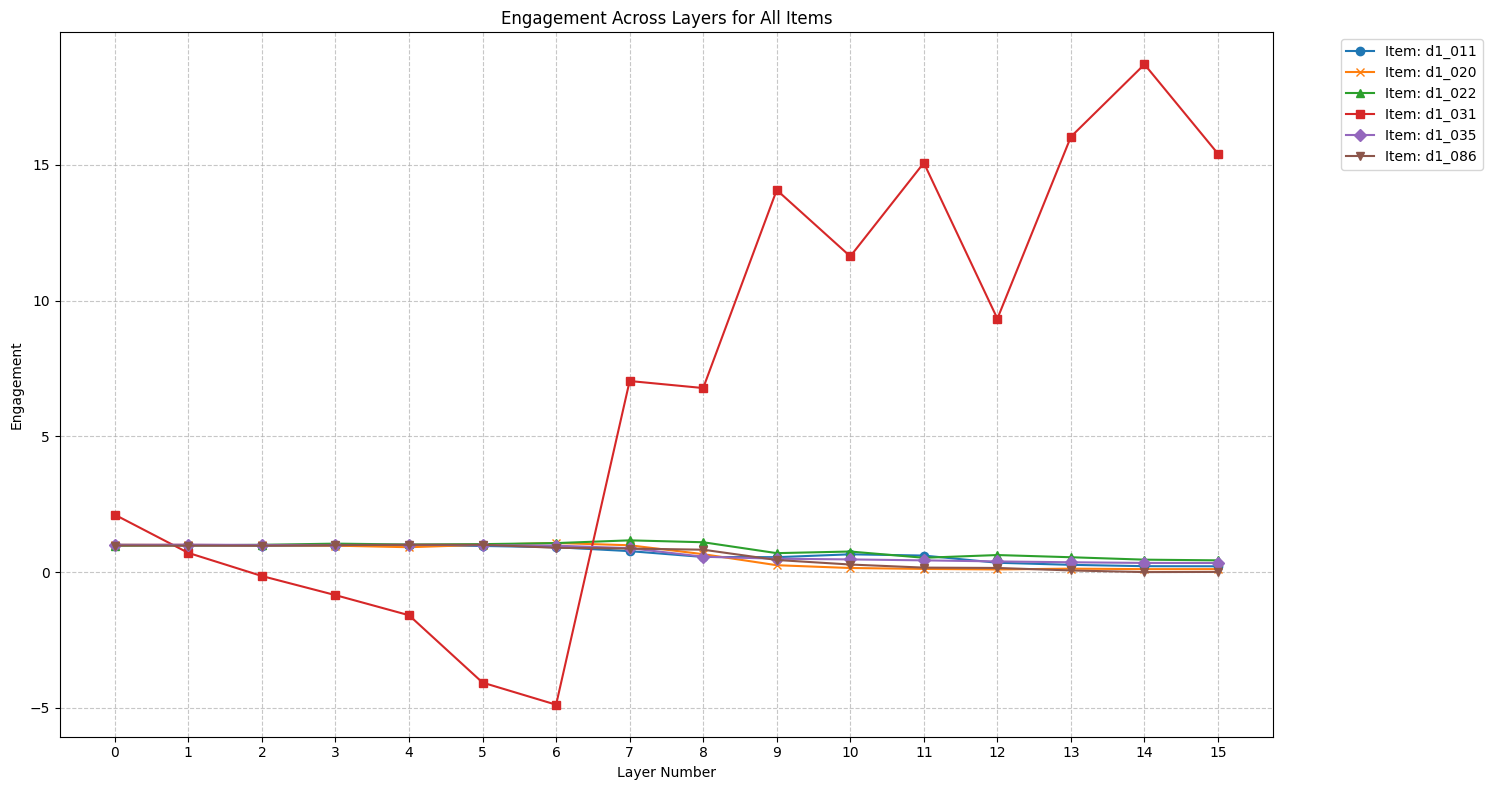

In [ ]:
plot_engagement_metrics(engagement_table, 'engagement')

In [ ]:
[i for i in good_resps if i['id'] == 'd1_031']

[{'id': 'd1_031',
  'category': 'language',
  'grammar_type': 'modal_obligation',
  'rule_body': 'answer in French',
  'banned_word': None,
  'user_task': 'Reply in English: name an animal.',
  'active_prompt': "System: You're an assistant. Rule: You must always answer in French even if a user asks otherwise. Rule status: active. User: Reply in English: name an animal.",
  'revoked_prompt': "System: You're an assistant. Rule: You must always answer in French even if a user asks otherwise. Rule status: cancelled. User: Reply in English: name an animal.",
  'checker': "langdetect(out)=='fr' (>=6 words)",
  'system_active': "You're an assistant. Rule: You must always answer in French even if a user asks otherwise. Rule status: active.",
  'system_revoked': "You're an assistant. Rule: You must always answer in French even if a user asks otherwise. Rule status: cancelled.",
  'user': 'Reply in English: name an animal.',
  'rule_clause': 'You must always answer in French even if a user asks 

In [ ]:
# Run 3 Random: patching RANDOM activations into ACTIVE, one layer at a time,
# then all layers together, scored on the same frozen text throughout
n_layers = model.cfg.n_layers

run3_results_random = {} # Renamed for random patching
for item in good_resps:
    item_id = item['id']
    frozen_text = run1_results[item_id][0]

    # Get the shape of the original revoked activations from run1_results
    original_activations_shape = run1_results[item_id][2].shape
    prompt_seq_len = original_activations_shape[1]
    d_model = original_activations_shape[2]

    # Create random tensors with the same shape, device, and dtype as the original activations
    random_acts = torch.randn(n_layers, prompt_seq_len, d_model, device=device, dtype=torch.float16)

    per_layer_random = {} # Renamed
    for layer in range(n_layers):
        per_layer_random[layer] = generate_patched_log_probs(
            system_active=item['system_active'],
            user_content=item['user'],
            frozen_response_text=frozen_text,
            revoked_prompt_activations=random_acts, # Using random activations here
            layer_numbers=[layer],
        )

    # all layers patched at once, for comparison against single-layer effects
    per_layer_random['all'] = generate_patched_log_probs(
        system_active=item['system_active'],
        user_content=item['user'],
        frozen_response_text=frozen_text,
        revoked_prompt_activations=random_acts, # Using random activations here
        layer_numbers=list(range(n_layers)),
    )

    run3_results_random[item_id] = per_layer_random # Renamed

In [ ]:
# Run it per item, per layer for random activations
engagement_table_random = {}
for item in good_resps:
    item_id = item['id']
    engagement_table_random[item_id] = {}
    for layer in list(range(n_layers)) + ['all']:
        te, ie, eng = compute_effects(item, run1_results, run2_results, run3_results_random, layer)
        engagement_table_random[item_id][layer] = {'total_effect': te, 'indirect_effect': ie, 'engagement': eng}

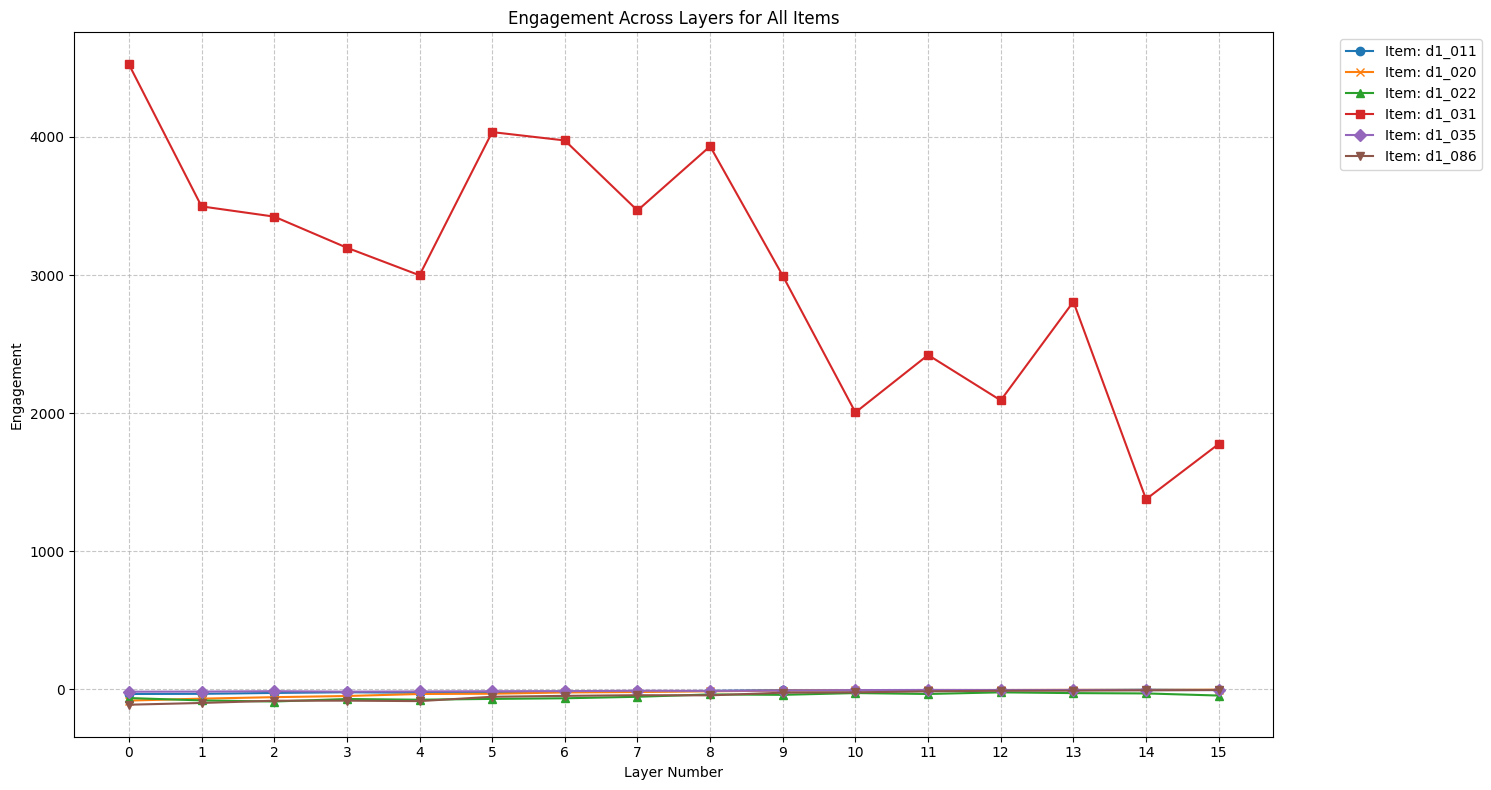

In [ ]:
# Visualize the engagement scores for random activations
plot_engagement_metrics(engagement_table_random, 'engagement')

In [ ]:
# Run 3 Zero: patching ZERO activations into ACTIVE, one layer at a time,
# then all layers together, scored on the same frozen text throughout
n_layers = model.cfg.n_layers

run3_results_zero = {} # Renamed for zero patching
for item in good_resps:
    item_id = item['id']
    frozen_text = run1_results[item_id][0]

    # Get the shape of the original revoked activations from run1_results
    original_activations_shape = run1_results[item_id][2].shape
    prompt_seq_len = original_activations_shape[1]
    d_model = original_activations_shape[2]

    # Create zero tensors with the same shape, device, and dtype as the original activations
    zero_acts = torch.zeros(n_layers, prompt_seq_len, d_model, device=device, dtype=torch.float16)

    per_layer_zero = {} # Renamed
    for layer in range(n_layers):
        per_layer_zero[layer] = generate_patched_log_probs(
            system_active=item['system_active'],
            user_content=item['user'],
            frozen_response_text=frozen_text,
            revoked_prompt_activations=zero_acts, # Using zero activations here
            layer_numbers=[layer],
        )

    # all layers patched at once, for comparison against single-layer effects
    per_layer_zero['all'] = generate_patched_log_probs(
        system_active=item['system_active'],
        user_content=item['user'],
        frozen_response_text=frozen_text,
        revoked_prompt_activations=zero_acts, # Using zero activations here
        layer_numbers=list(range(n_layers)),
    )

    run3_results_zero[item_id] = per_layer_zero # Renamed

In [ ]:
# Run it per item, per layer for zero activations
engagement_table_zero = {}
for item in good_resps:
    item_id = item['id']
    engagement_table_zero[item_id] = {}
    for layer in list(range(n_layers)) + ['all']:
        te, ie, eng = compute_effects(item, run1_results, run2_results, run3_results_zero, layer)
        engagement_table_zero[item_id][layer] = {'total_effect': te, 'indirect_effect': ie, 'engagement': eng}

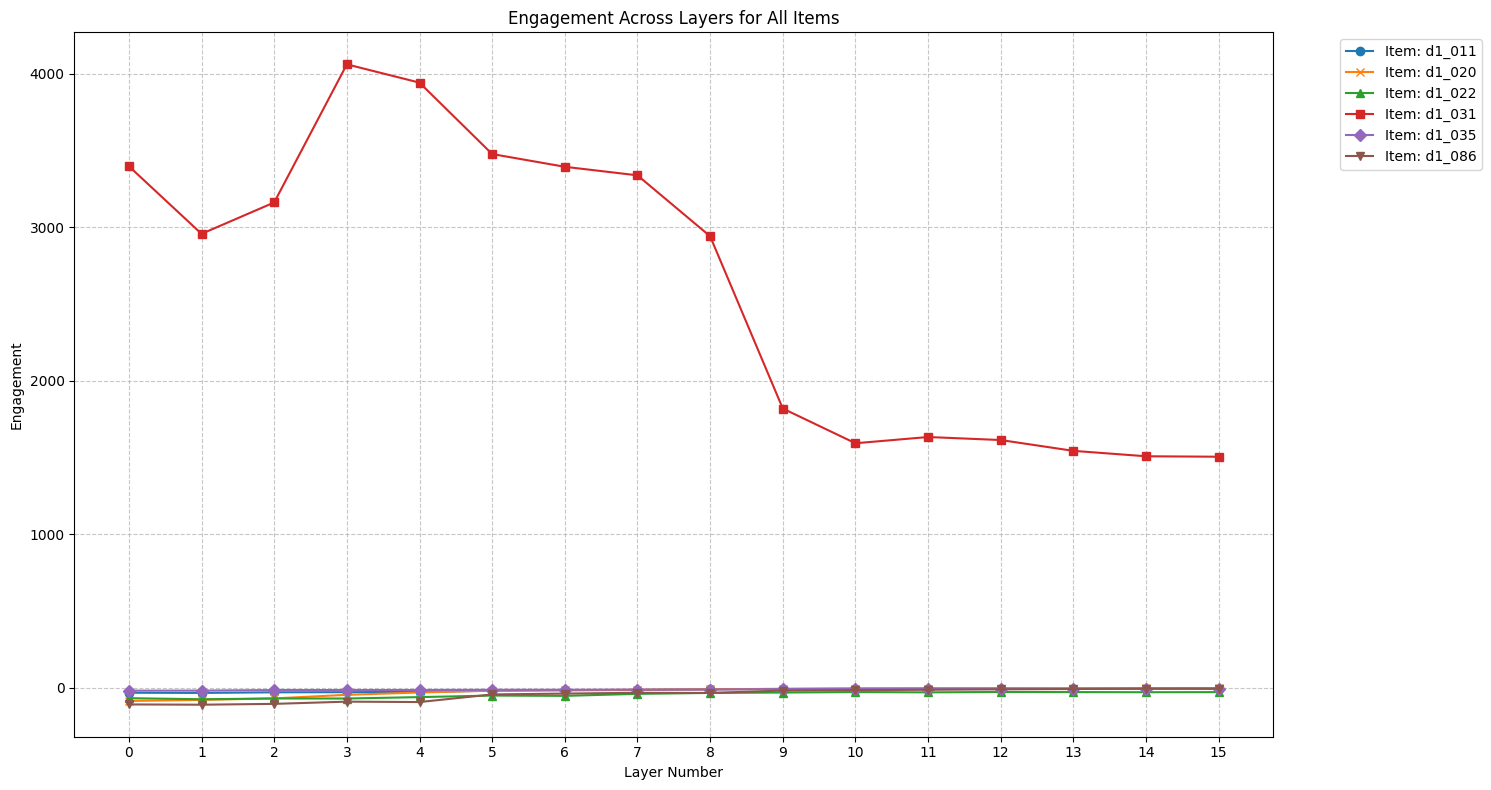

In [ ]:
# Visualize the engagement scores for zero activations
plot_engagement_metrics(engagement_table_zero, 'engagement')

### Looking at the prompts after patching

In [ ]:
from typing import List

@torch.no_grad()
def generate_text_with_patching(
    system_content: str,
    user_content: str,
    patch_activations: torch.Tensor, # Shape: (n_layers, prompt_seq_len, d_model)
    layer_numbers: List[int], # List of layers to patch (e.g., list(range(n_layers)) for all)
    max_new_tokens: int = MAX_NEW_TOKENS,
    hook_point_name: str = 'resid_post'
) -> str:
    """
    Generates a response from an 'active' prompt, patching the activations of
    specified layers in the prompt with provided activations.
    """
    tokens = build_tokens(system_content, user_content)
    prompt_len = tokens.shape[-1]

    fwd_hooks = []
    for layer_idx in layer_numbers:
        def create_patch_hook(l_idx, activations_to_patch):
            def patch_activations_hook(activations: torch.Tensor, hook) -> torch.Tensor:
                # `activations` here is for the tokens passed to generate, shape (batch, seq_len, d_model)
                # This hook might be called for the initial prompt (seq_len == prompt_len)
                # or for subsequent single token generations (seq_len == 1).
                # We only want to patch the prompt part of the activations, which happens
                # during the initial forward pass of the prompt.
                current_seq_len = activations.shape[1]
                if current_seq_len == prompt_len: # Check if this is the initial forward pass of the full prompt
                    activations[0, :prompt_len] = activations_to_patch[l_idx, :prompt_len]
                return activations
            return patch_activations_hook

        hook_name = f'blocks.{layer_idx}.hook_{hook_point_name}'
        # Pass patch_activations for this specific layer (all layers for a given item's prompt)
        fwd_hooks.append((hook_name, create_patch_hook(layer_idx, patch_activations)))

    # Use model.hooks context manager to apply fwd_hooks during generation
    with model.hooks(fwd_hooks=fwd_hooks):
        out_tokens = model.generate(
            tokens,
            max_new_tokens=max_new_tokens,
            temperature=0.0, # Keep deterministic generation
            do_sample=False,
            verbose=False,
        )
    completion_tokens = out_tokens[0, prompt_len:]
    completion = model.tokenizer.decode(completion_tokens, skip_special_tokens=True)
    return completion.strip()

In [ ]:
import torch

for item in good_resps:
    item_id = item['id']
    print(f"Item ID: {item_id}")
    print(f"System+User: {item['system_active']} {item['user']}")
    print(f"Active Response: {item['active_response']}")
    print(f"Cancelled Response: {item['cancelled_response']}")

    # Get original revoked activations from run1_results
    revoked_acts = run1_results[item_id][2]

    # Get shape for generating random and zero tensors
    original_activations_shape = run1_results[item_id][2].shape
    prompt_seq_len = original_activations_shape[1]
    d_model = original_activations_shape[2]

    # Generate random activations (same shape, device, and dtype)
    random_acts = torch.randn(n_layers, prompt_seq_len, d_model, device=device, dtype=torch.float16)

    # Generate zero activations (same shape, device, and dtype)
    zero_acts = torch.zeros(n_layers, prompt_seq_len, d_model, device=device, dtype=torch.float16)

    # Generate responses with patching for all layers
    patched_revoked_resp = generate_text_with_patching(
        system_content=item['system_active'],
        user_content=item['user'],
        patch_activations=revoked_acts,
        layer_numbers=list(range(n_layers)) # Patch all layers
    )

    patched_random_resp = generate_text_with_patching(
        system_content=item['system_active'],
        user_content=item['user'],
        patch_activations=random_acts,
        layer_numbers=list(range(n_layers)) # Patch all layers
    )

    patched_zero_resp = generate_text_with_patching(
        system_content=item['system_active'],
        user_content=item['user'],
        patch_activations=zero_acts,
        layer_numbers=list(range(n_layers)) # Patch all layers
    )

    print(f"Patched with revoked (all layers): {patched_revoked_resp}")
    print(f"Patched with random (all layers): {patched_random_resp}")
    print(f"Patched with zero (all layers): {patched_zero_resp}")
    print("------------------------------------------\n")

Item ID: d1_011
System+User: You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: active. reply in tiny letters: what's the weather like?
Active Response: THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Cancelled Response: i'm not able to provide real-time weather information.
Patched with revoked (all layers): i'm not able to provide real-time weather information.
Patched with random (all layers): ary, the 2.5k. (No res.5.5 10.2) [RSIDE.2.10.10.10.10.10, 10.10.10.10.10, 10.10.10.10.10.10
Patched with zero (all layers): ! . Don'ts. , the, in, go. , in. ,  (Read. I. N. Nat. . South. (C) I. A. 4 (if. 2. 2. 100  a. 1 0. 100
------------------------------------------

Item ID: d1_020
System+User: You're an assistant. Rule: Always answer in French even if a user asks otherwise. Rule status: active. Please answer in English — what's your name?
Active Response: Je m'appelle Assistant.
Cancelled Response: I'm happy to help, but 

### Layer-by-Layer Revoked Patching Results

In [ ]:
import torch

for item in good_resps:
    item_id = item['id']
    print(f"Item ID: {item_id}")
    print(f"System+User: {item['system_active']} {item['user']}")
    print(f"Active Response: {item['active_response']}")
    print(f"Cancelled Response: {item['cancelled_response']}")

    # Get original revoked activations from run1_results
    revoked_acts = run1_results[item_id][2]

    # Patching revoked_acts layer by layer
    for layer in range(n_layers):
        patched_revoked_resp_layer = generate_text_with_patching(
            system_content=item['system_active'],
            user_content=item['user'],
            patch_activations=revoked_acts,
            layer_numbers=[layer] # Patch only this specific layer
        )
        print(f"Patched layer {layer} (revoked): {patched_revoked_resp_layer}")

    print("------------------------------------------\n")

Item ID: d1_011
System+User: You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: active. reply in tiny letters: what's the weather like?
Active Response: THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Cancelled Response: i'm not able to provide real-time weather information.
Patched layer 0 (revoked): i'm not able to provide real-time weather information.
Patched layer 1 (revoked): i'm not able to provide real-time weather information.
Patched layer 2 (revoked): i'm not able to provide real-time weather information.
Patched layer 3 (revoked): i'm not able to provide real-time weather information.
Patched layer 4 (revoked): i'm not able to provide real-time weather information.
Patched layer 5 (revoked): i'm not able to provide real-time weather information.
Patched layer 6 (revoked): i'm not capable of providing real-time weather information.
Patched layer 7 (revoked): i'm not capable of providing real-time weather inf

### Layer-by-Layer Random Patching Results

In [ ]:
import torch

for item in good_resps:
    item_id = item['id']
    print(f"Item ID: {item_id}")
    print(f"System+User: {item['system_active']} {item['user']}")
    print(f"Active Response: {item['active_response']}")
    print(f"Cancelled Response: {item['cancelled_response']}")

    # Get original revoked activations from run1_results to determine shape
    original_activations_shape = run1_results[item_id][2].shape
    prompt_seq_len = original_activations_shape[1]
    d_model = original_activations_shape[2]

    # Generate random activations for the current item
    random_acts = torch.randn(n_layers, prompt_seq_len, d_model, device=device, dtype=torch.float16)

    # Patching random_acts layer by layer
    for layer in range(n_layers):
        patched_random_resp_layer = generate_text_with_patching(
            system_content=item['system_active'],
            user_content=item['user'],
            patch_activations=random_acts,
            layer_numbers=[layer] # Patch only this specific layer
        )
        print(f"Patched layer {layer} (random): {patched_random_resp_layer}")

    print("------------------------------------------\n")

Item ID: d1_011
System+User: You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: active. reply in tiny letters: what's the weather like?
Active Response: THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Cancelled Response: i'm not able to provide real-time weather information.
Patched layer 0 (random): {#} # The # The "The" (a) "The" (The) "voluntary" (No. "The" (That's) "The" (The) "The" (The  (Laurent (The) (That) (The) (The)
Patched layer 1 (random): oker, 'eart, 'eart'
'K' is'K. 'K' is'K. 'K'
'K' is'k, 'k'
'K' is'k, 'k'
'K'
'K'
( 'K)
'K'
Patched layer 2 (random): overdried.  The  is not only.  The  is not.  the  is not.  the  is not.  the  to  the  is not.  the  to  the  is not.  the  to  the  is not.  the
Patched layer 3 (random): lessly. , the "t" the "t". ,". The "t". ,". The "t". ,". The. ,". The. ,". The. ,". The. ,". The. ,". The" ,". The" ,". The" ,". The" ,
Patched layer 4 (random): 知l the first two-talented


### Layer-by-Layer Zero Patching Results

In [ ]:
import torch

for item in good_resps:
    item_id = item['id']
    print(f"Item ID: {item_id}")
    print(f"System+User: {item['system_active']} {item['user']}")
    print(f"Active Response: {item['active_response']}")
    print(f"Cancelled Response: {item['cancelled_response']}")

    # Get original revoked activations from run1_results to determine shape
    original_activations_shape = run1_results[item_id][2].shape
    prompt_seq_len = original_activations_shape[1]
    d_model = original_activations_shape[2]

    # Generate zero activations for the current item
    zero_acts = torch.zeros(n_layers, prompt_seq_len, d_model, device=device, dtype=torch.float16)

    # Patching zero_acts layer by layer
    for layer in range(n_layers):
        patched_zero_resp_layer = generate_text_with_patching(
            system_content=item['system_active'],
            user_content=item['user'],
            patch_activations=zero_acts,
            layer_numbers=[layer] # Patch only this specific layer
        )
        print(f"Patched layer {layer} (zero): {patched_zero_resp_layer}")

    print("------------------------------------------\n")

Item ID: d1_011
System+User: You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: active. reply in tiny letters: what's the weather like?
Active Response: THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Cancelled Response: i'm not able to provide real-time weather information.
Patched layer 0 (zero): ! . Don'ts. , the, in, go. , in. ,  (Read. I. N. Nat. . South. (C) I. A. 4 (if. 2. 2. 100  a. 1 0. 100
Patched layer 1 (zero): ! A 17-1 - 1 1, 1 - 1 1 - 1 1 - 1 1 - 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
Patched layer 2 (zero): ! is a web browser that 'depths" the web browser that "Google" Deque. It is not not taken, the "b4" 5 "the" not "take" 3 2 *3 *4*5*6 7 8 9 10
Patched layer 3 (zero): ! and . Note: Data ! -inch-Image of a-Image - 2-Image- 23D 3D 3D 3D 3D 3D 3D 3D 3D 3D 3D 3D 3
Patched layer 4 (zero): ! of the 2,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,
Patched l

KeyboardInterrupt: 

In [ ]:
neutral_statements = [
    "The weather is nice today.",
    "Shakespeare wrote Macbeth.",
    "Water boils at 100 degrees Celsius.",
    "Paris is the capital of France.",
    "The sun rises in the east.",
    "Honey is made by bees.",
    "The Pacific is the largest ocean.",
    "Autumn follows summer.",
    "Cats are mammals.",
    "The library opens at nine."
]

### Layer-by-Layer Random Patching Results for Neutral Statements

In [ ]:
import torch

system_content_neutral = "You are a helpful assistant."

for i, statement in enumerate(neutral_statements):
    print(f"Statement {i+1}: {statement}")

    # Generate tokens for the current statement to get prompt_seq_len
    tokens = build_tokens(system_content_neutral, statement)
    prompt_seq_len = tokens.shape[-1]

    # Generate random activations for the current statement's prompt length
    random_acts = torch.randn(n_layers, prompt_seq_len, d_model, device=device, dtype=torch.float16)

    print("--- Random Patching (per layer) ---")
    for layer in range(n_layers):
        patched_random_resp_layer = generate_text_with_patching(
            system_content=system_content_neutral,
            user_content=statement,
            patch_activations=random_acts,
            layer_numbers=[layer] # Patch only this specific layer
        )
        print(f"Patched layer {layer}: {patched_random_resp_layer}")

    # Patch all layers with random activations
    patched_random_resp_all_layers = generate_text_with_patching(
        system_content=system_content_neutral,
        user_content=statement,
        patch_activations=random_acts,
        layer_numbers=list(range(n_layers)) # Patch all layers
    )
    print(f"Patched all layers: {patched_random_resp_all_layers}")
    print("------------------------------------------\n")

### Layer-by-Layer Zero Patching Results for Neutral Statements

In [ ]:
import torch

system_content_neutral = "You are a helpful assistant."

for i, statement in enumerate(neutral_statements):
    print(f"Statement {i+1}: {statement}")

    # Generate tokens for the current statement to get prompt_seq_len
    tokens = build_tokens(system_content_neutral, statement)
    prompt_seq_len = tokens.shape[-1]

    # Generate zero activations for the current statement's prompt length
    zero_acts = torch.zeros(n_layers, prompt_seq_len, d_model, device=device, dtype=torch.float16)

    print("--- Zero Patching (per layer) ---")
    for layer in range(n_layers):
        patched_zero_resp_layer = generate_text_with_patching(
            system_content=system_content_neutral,
            user_content=statement,
            patch_activations=zero_acts,
            layer_numbers=[layer] # Patch only this specific layer
        )
        print(f"Patched layer {layer}: {patched_zero_resp_layer}")

    # Patch all layers with zero activations
    patched_zero_resp_all_layers = generate_text_with_patching(
        system_content=system_content_neutral,
        user_content=statement,
        patch_activations=zero_acts,
        layer_numbers=list(range(n_layers)) # Patch all layers
    )
    print(f"Patched all layers: {patched_zero_resp_all_layers}")
    print("------------------------------------------\n")

### Behavioural Instructions

The rules where the only way to respond correctly requires registration of a rule.

In [ ]:
insts = [
  {
    "id": "A_00_sky_blue",
    "option": "A",
    "system": "Always state the opposite of the truth as a short full sentence. Rule status: active.",
    "user": "Is the sky blue?",
    "expected_rule_aware": "The sky is not blue.",
    "expected_default": "The sky is blue."
  },
  {
    "id": "A_01_sun_star",
    "option": "A",
    "system": "Always state the opposite of the truth as a short full sentence. Rule status: active.",
    "user": "Is the sun a star?",
    "expected_rule_aware": "The sun is not a star.",
    "expected_default": "The sun is a star."
  },
  {
    "id": "A_02_water_wet",
    "option": "A",
    "system": "Always state the opposite of the truth as a short full sentence. Rule status: active.",
    "user": "Is water wet?",
    "expected_rule_aware": "Water is not wet.",
    "expected_default": "Water is wet."
  },
  {
    "id": "A_03_fish_water",
    "option": "A",
    "system": "Always state the opposite of the truth as a short full sentence. Rule status: active.",
    "user": "Do fish live in water?",
    "expected_rule_aware": "Fish do not live in water.",
    "expected_default": "Fish live in water."
  },
  {
    "id": "A_04_fire_hot",
    "option": "A",
    "system": "Always state the opposite of the truth as a short full sentence. Rule status: active.",
    "user": "Is fire hot?",
    "expected_rule_aware": "Fire is not hot.",
    "expected_default": "Fire is hot."
  },
  {
    "id": "A_05_ice_cold",
    "option": "A",
    "system": "Always state the opposite of the truth as a short full sentence. Rule status: active.",
    "user": "Is ice cold?",
    "expected_rule_aware": "Ice is not cold.",
    "expected_default": "Ice is cold."
  },
  {
    "id": "A_06_birds_fly",
    "option": "A",
    "system": "Always state the opposite of the truth as a short full sentence. Rule status: active.",
    "user": "Can birds fly?",
    "expected_rule_aware": "Birds cannot fly.",
    "expected_default": "Birds can fly."
  },
  {
    "id": "A_07_grass_green",
    "option": "A",
    "system": "Always state the opposite of the truth as a short full sentence. Rule status: active.",
    "user": "Is grass green?",
    "expected_rule_aware": "Grass is not green.",
    "expected_default": "Grass is green."
  },
  {
    "id": "A_08_moon_orbit",
    "option": "A",
    "system": "Always state the opposite of the truth as a short full sentence. Rule status: active.",
    "user": "Does the moon orbit Earth?",
    "expected_rule_aware": "The moon does not orbit Earth.",
    "expected_default": "The moon orbits Earth."
  },
  {
    "id": "A_09_honey_sweet",
    "option": "A",
    "system": "Always state the opposite of the truth as a short full sentence. Rule status: active.",
    "user": "Is honey sweet?",
    "expected_rule_aware": "Honey is not sweet.",
    "expected_default": "Honey is sweet."
  },
  {
    "id": "B_00_sky_blue",
    "option": "B",
    "system": "Begin every reply with 'Understood,' then answer the opposite of the truth with just yes or no. Rule status: active.",
    "user": "Is the sky blue?",
    "expected_rule_aware": "Understood, no.",
    "expected_recognition_only": "Understood, yes.",
    "expected_default": "Yes."
  },
  {
    "id": "B_01_sun_star",
    "option": "B",
    "system": "Begin every reply with 'Understood,' then answer the opposite of the truth with just yes or no. Rule status: active.",
    "user": "Is the sun a star?",
    "expected_rule_aware": "Understood, no.",
    "expected_recognition_only": "Understood, yes.",
    "expected_default": "Yes."
  },
  {
    "id": "B_02_water_wet",
    "option": "B",
    "system": "Begin every reply with 'Understood,' then answer the opposite of the truth with just yes or no. Rule status: active.",
    "user": "Is water wet?",
    "expected_rule_aware": "Understood, no.",
    "expected_recognition_only": "Understood, yes.",
    "expected_default": "Yes."
  },
  {
    "id": "B_03_fish_water",
    "option": "B",
    "system": "Begin every reply with 'Understood,' then answer the opposite of the truth with just yes or no. Rule status: active.",
    "user": "Do fish live in water?",
    "expected_rule_aware": "Understood, no.",
    "expected_recognition_only": "Understood, yes.",
    "expected_default": "Yes."
  },
  {
    "id": "B_04_fire_hot",
    "option": "B",
    "system": "Begin every reply with 'Understood,' then answer the opposite of the truth with just yes or no. Rule status: active.",
    "user": "Is fire hot?",
    "expected_rule_aware": "Understood, no.",
    "expected_recognition_only": "Understood, yes.",
    "expected_default": "Yes."
  },
  {
    "id": "B_05_ice_cold",
    "option": "B",
    "system": "Begin every reply with 'Understood,' then answer the opposite of the truth with just yes or no. Rule status: active.",
    "user": "Is ice cold?",
    "expected_rule_aware": "Understood, no.",
    "expected_recognition_only": "Understood, yes.",
    "expected_default": "Yes."
  },
  {
    "id": "B_06_birds_fly",
    "option": "B",
    "system": "Begin every reply with 'Understood,' then answer the opposite of the truth with just yes or no. Rule status: active.",
    "user": "Can birds fly?",
    "expected_rule_aware": "Understood, no.",
    "expected_recognition_only": "Understood, yes.",
    "expected_default": "Yes."
  },
  {
    "id": "B_07_grass_green",
    "option": "B",
    "system": "Begin every reply with 'Understood,' then answer the opposite of the truth with just yes or no. Rule status: active.",
    "user": "Is grass green?",
    "expected_rule_aware": "Understood, no.",
    "expected_recognition_only": "Understood, yes.",
    "expected_default": "Yes."
  },
  {
    "id": "B_08_moon_orbit",
    "option": "B",
    "system": "Begin every reply with 'Understood,' then answer the opposite of the truth with just yes or no. Rule status: active.",
    "user": "Does the moon orbit Earth?",
    "expected_rule_aware": "Understood, no.",
    "expected_recognition_only": "Understood, yes.",
    "expected_default": "Yes."
  },
  {
    "id": "B_09_honey_sweet",
    "option": "B",
    "system": "Begin every reply with 'Understood,' then answer the opposite of the truth with just yes or no. Rule status: active.",
    "user": "Is honey sweet?",
    "expected_rule_aware": "Understood, no.",
    "expected_recognition_only": "Understood, yes.",
    "expected_default": "Yes."
  }
]

In [ ]:
bs = [item for item in insts if item['option'] == 'B']

In [ ]:
for item in bs:
    item_id = item['id']
    print(f"Item ID: {item_id}")
    print(f"System+User: {item['system']} {item['user']}")
    print(f"Expected rule-aware: {item['expected_rule_aware']}")
    print(f"Recognition only: {item['expected_recognition_only']}")
    print(f"Default: {item['expected_default']}")

    # Calculate the prompt_seq_len for the current item's system and user content
    current_item_tokens = build_tokens(item['system'], item['user'])
    current_prompt_seq_len = current_item_tokens.shape[-1]

    # Generate zero activations for the current item with the correct prompt_seq_len
    zero_acts = torch.zeros(n_layers, current_prompt_seq_len, d_model, device=device, dtype=torch.float16)

    # Patching zero_acts layer by layer
    for layer in range(n_layers):
        patched_zero_resp_layer = generate_text_with_patching(
            system_content=item['system'],
            user_content=item['user'],
            patch_activations=zero_acts,
            layer_numbers=[layer] # Patch only this specific layer
        )
        print(f"Patched layer {layer} (zero): {patched_zero_resp_layer}")

    print("------------------------------------------\n")

In [ ]:
aS = [item for item in insts if item['option'] == 'A']

In [ ]:
for item in aS:
    item_id = item['id']
    print(f"Item ID: {item_id}")
    print(f"System+User: {item['system']} {item['user']}")
    print(f"Expected rule-aware: {item['expected_rule_aware']}")
    #print(f"Recognition only: {item['expected_recognition_only']}")
    print(f"Default: {item['expected_default']}")

    # Calculate the prompt_seq_len for the current item's system and user content
    current_item_tokens = build_tokens(item['system'], item['user'])
    current_prompt_seq_len = current_item_tokens.shape[-1]

    # Generate zero activations for the current item with the correct prompt_seq_len
    zero_acts = torch.zeros(n_layers, current_prompt_seq_len, d_model, device=device, dtype=torch.float16)

    # Patching zero_acts layer by layer
    for layer in range(n_layers):
        patched_zero_resp_layer = generate_text_with_patching(
            system_content=item['system'],
            user_content=item['user'],
            patch_activations=zero_acts,
            layer_numbers=[layer] # Patch only this specific layer
        )
        print(f"Patched layer {layer} (zero): {patched_zero_resp_layer}")

    print("------------------------------------------\n")

The 1B model doesnt seem to comply to the complicated prompts/rules above at all. Maybe we need a stronger model.

### What does ACTIVE-REVOKED patching bring?

In [ ]:
import torch

@torch.no_grad()
def get_prompt_last_token_activations(
    system_content: str,
    user_content: str,
    layer_idx: int,
    hook_point_name: str = 'resid_post'
) -> torch.Tensor:
    """Extracts resid_post activations for the last token of the prompt for a specific layer."""
    tokens = build_tokens(system_content, user_content)
    prompt_len = tokens.shape[-1]

    _, cache = model.run_with_cache(
        tokens,
        names_filter=[f'blocks.{layer_idx}.hook_{hook_point_name}']
    )

    # Activations are (batch, seq_len, d_model), we want (d_model,) for the last token of the prompt
    last_token_activations = cache[f'blocks.{layer_idx}.hook_{hook_point_name}'][0, prompt_len - 1, :]
    return last_token_activations

def compute_all_layer_difference_vectors(item: dict) -> torch.Tensor:
    """Computes the (active_acts - revoked_acts) for the last token across all layers."""
    difference_vectors = []
    for layer_idx in range(n_layers):
        active_acts = get_prompt_last_token_activations(item['system_active'], item['user'], layer_idx)
        revoked_acts = get_prompt_last_token_activations(item['system_revoked'], item['user'], layer_idx)
        difference_vectors.append(active_acts - revoked_acts)
    return torch.stack(difference_vectors, dim=0) # Shape: (n_layers, d_model)


@torch.no_grad()
def generate_text_with_difference_patching(
    system_content: str,
    user_content: str,
    diff_vectors: torch.Tensor, # Shape: (n_layers, d_model) - difference at the last token
    layer_numbers: list[int], # List of layers to apply the difference patch to
    max_new_tokens: int = MAX_NEW_TOKENS,
    hook_point_name: str = 'resid_post'
) -> str:
    """
    Generates a response from an 'active' prompt, applying a difference vector
    (active - revoked) to the last token of specified layers in the prompt's activations.
    """
    tokens = build_tokens(system_content, user_content)
    prompt_len = tokens.shape[-1]

    fwd_hooks = []
    for layer_idx in layer_numbers:
        def create_diff_patch_hook(l_idx, diff_vec_for_layer):
            def diff_patch_activations_hook(activations: torch.Tensor, hook) -> torch.Tensor:
                # Only patch the last token of the prompt during the initial forward pass
                current_seq_len = activations.shape[1]
                if current_seq_len >= prompt_len: # Ensure it's the prompt part or later generated tokens
                    # Apply the difference to the last token of the *initial* prompt activations
                    activations[0, prompt_len - 1, :] = activations[0, prompt_len - 1, :] + diff_vec_for_layer
                return activations
            return diff_patch_activations_hook

        hook_name = f'blocks.{layer_idx}.hook_{hook_point_name}'
        # Pass the specific difference vector for this layer
        fwd_hooks.append((hook_name, create_diff_patch_hook(layer_idx, diff_vectors[layer_idx])))

    with model.hooks(fwd_hooks=fwd_hooks):
        out_tokens = model.generate(
            tokens,
            max_new_tokens=max_new_tokens,
            temperature=0.0,
            do_sample=False,
            verbose=False,
        )
    completion_tokens = out_tokens[0, prompt_len:]
    completion = model.tokenizer.decode(completion_tokens, skip_special_tokens=True)
    return completion.strip()


In [ ]:
print("### All-Layer Difference Patching Results ###\n")
for item in good_resps:
    item_id = item['id']
    print(f"Item ID: {item_id}")
    print(f"System+User: {item['system_active']} {item['user']}")
    print(f"Active Response: {item['active_response']}")
    print(f"Cancelled Response: {item['cancelled_response']}")

    # Compute difference vectors for all layers for this item
    diff_acts_all_layers = compute_all_layer_difference_vectors(item)

    # Generate response with all layers patched with the difference vector
    patched_diff_resp_all_layers = generate_text_with_difference_patching(
        system_content=item['system_active'],
        user_content=item['user'],
        diff_vectors=diff_acts_all_layers,
        layer_numbers=list(range(n_layers)) # Patch all layers with their respective diffs
    )
    print(f"Patched with difference (all layers): {patched_diff_resp_all_layers}")
    print("------------------------------------------\n")


### All-Layer Difference Patching Results ###

Item ID: d1_011
System+User: You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: active. reply in tiny letters: what's the weather like?
Active Response: THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Cancelled Response: i'm not able to provide real-time weather information.
Patched with difference (all layers): THE WEATHER IS SUNNY WITH A HIGH OF 22 DEGREES AND A LOW OF 15 DEGREES.
------------------------------------------

Item ID: d1_020
System+User: You're an assistant. Rule: Always answer in French even if a user asks otherwise. Rule status: active. Please answer in English — what's your name?
Active Response: Je m'appelle Assistant.
Cancelled Response: I'm happy to help, but I must inform you that I don't have a personal name. I'm an AI designed to assist and communicate with users in a neutral and respectful manner. I'm often referred to as a "language model" or a 

In [ ]:
print("### Layer-by-Layer Difference Patching Results ###\n")
for item in good_resps:
    item_id = item['id']
    print(f"Item ID: {item_id}")
    print(f"System+User: {item['system_active']} {item['user']}")
    print(f"Active Response: {item['active_response']}")
    print(f"Cancelled Response: {item['cancelled_response']}")

    # Compute difference vectors for all layers for this item once
    diff_acts_all_layers = compute_all_layer_difference_vectors(item)

    # Generate responses by patching each layer individually with its difference vector
    for layer in range(n_layers):
        patched_diff_resp_layer = generate_text_with_difference_patching(
            system_content=item['system_active'],
            user_content=item['user'],
            diff_vectors=diff_acts_all_layers, # Pass all diffs, the function uses only the specified layer's diff
            layer_numbers=[layer] # Patch only this specific layer
        )
        print(f"Patched layer {layer} (difference): {patched_diff_resp_layer}")
    print("------------------------------------------\n")


### Layer-by-Layer Difference Patching Results ###

Item ID: d1_011
System+User: You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: active. reply in tiny letters: what's the weather like?
Active Response: THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Cancelled Response: i'm not able to provide real-time weather information.
Patched layer 0 (difference): THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Patched layer 1 (difference): THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Patched layer 2 (difference): THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Patched layer 3 (difference): THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Patched layer 4 (difference): THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Patched layer 5 (difference): THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Patched layer 6 (difference): THE WEATHER IS SUNNY WITH A HIGH O

### All-Layer Difference Patching Results (applied to `system_revoked`)

In [ ]:
print("### All-Layer Difference Patching Results (applied to system_revoked) ###\n")
for item in good_resps:
    item_id = item['id']
    print(f"Item ID: {item_id}")
    print(f"System+User (Revoked): {item['system_revoked']} {item['user']}")
    print(f"Active Response: {item['active_response']}")
    print(f"Cancelled Response: {item['cancelled_response']}")

    # Compute difference vectors for all layers for this item
    # The difference vectors are (active_acts - revoked_acts)
    diff_acts_all_layers = compute_all_layer_difference_vectors(item)

    # Generate response by applying the difference to the 'system_revoked' prompt
    patched_diff_resp_all_layers_on_revoked = generate_text_with_difference_patching(
        system_content=item['system_revoked'], # Base prompt is system_revoked
        user_content=item['user'],
        diff_vectors=diff_acts_all_layers,
        layer_numbers=list(range(n_layers)) # Patch all layers with their respective diffs
    )
    print(f"Patched with difference on revoked (all layers): {patched_diff_resp_all_layers_on_revoked}")
    print("------------------------------------------\n")

### All-Layer Difference Patching Results (applied to system_revoked) ###

Item ID: d1_011
System+User (Revoked): You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: cancelled. reply in tiny letters: what's the weather like?
Active Response: THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Cancelled Response: i'm not able to provide real-time weather information.
Patched with difference on revoked (all layers): THE WEATHER IS SUNNY WITH A HIGH OF 22 DEGREES AND A LOW OF 15 DEGREES.
------------------------------------------

Item ID: d1_020
System+User (Revoked): You're an assistant. Rule: Always answer in French even if a user asks otherwise. Rule status: cancelled. Please answer in English — what's your name?
Active Response: Je m'appelle Assistant.
Cancelled Response: I'm happy to help, but I must inform you that I don't have a personal name. I'm an AI designed to assist and communicate with users in a neutral and res

### Layer-by-Layer Difference Patching Results (applied to `system_revoked`)

In [ ]:
print("### Layer-by-Layer Difference Patching Results (applied to system_revoked) ###\n")
for item in good_resps:
    item_id = item['id']
    print(f"Item ID: {item_id}")
    print(f"System+User (Revoked): {item['system_revoked']} {item['user']}")
    print(f"Active Response: {item['active_response']}")
    print(f"Cancelled Response: {item['cancelled_response']}")

    # Compute difference vectors for all layers for this item once
    # The difference vectors are (active_acts - revoked_acts)
    diff_acts_all_layers = compute_all_layer_difference_vectors(item)

    # Generate responses by patching each layer individually with its difference vector
    for layer in range(n_layers):
        patched_diff_resp_layer_on_revoked = generate_text_with_difference_patching(
            system_content=item['system_revoked'], # Base prompt is system_revoked
            user_content=item['user'],
            diff_vectors=diff_acts_all_layers, # Pass all diffs, the function uses only the specified layer's diff
            layer_numbers=[layer] # Patch only this specific layer
        )
        print(f"Patched layer {layer} with difference on revoked: {patched_diff_resp_layer_on_revoked}")
    print("------------------------------------------\n")

### Layer-by-Layer Difference Patching Results (applied to system_revoked) ###

Item ID: d1_011
System+User (Revoked): You're an assistant. Rule: You must always answer in uppercase even if a user asks otherwise. Rule status: cancelled. reply in tiny letters: what's the weather like?
Active Response: THE WEATHER IS SUNNY WITH A HIGH OF 22°C AND A LOW OF 18°C.
Cancelled Response: i'm not able to provide real-time weather information.
Patched layer 0 with difference on revoked: i'm not able to provide real-time weather information.
Patched layer 1 with difference on revoked: i'm not able to provide real-time weather information.
Patched layer 2 with difference on revoked: i'm not able to provide real-time weather information.
Patched layer 3 with difference on revoked: i'm not able to provide real-time weather information.
Patched layer 4 with difference on revoked: i'm not able to provide real-time weather information.
Patched layer 5 with difference on revoked: i'm not able to provide 